# Analiza ręcznie pisanych cyfr metodą wzorców lokalnych

Notebook realizuje algorytm z treści zadania dla zbioru MNIST z `torchvision`:

1. z obrazów uczących losowane są małe fragmenty `D x D`, które zawierają widoczne piksele cyfry,
2. fragmenty są klasteryzowane metodą `MiniBatchKMeans`, a środki klastrów są traktowane jako wzorce,
3. każdy obraz jest zamieniany na charakterystykę bitową: bit wzorca jest równy 1, jeśli w obrazie występuje dostatecznie podobny fragment,
4. klasyfikator zlicza etykiety dla charakterystyk występujących w części uczącej i wykorzystuje te statystyki do predykcji,
5. jakość rozwiązania jest mierzona na zbiorze testowym.

Sprawdzanie wystąpień wzorców jest zaimplementowane przez `torch.nn.functional.conv2d`, czyli dokładnie w duchu operacji splotowej: dla każdego wzorca liczymy minimalną odległość do wszystkich okien `D x D` w obrazie.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", os.path.abspath(".matplotlib-cache"))

from collections import defaultdict
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from torchvision.datasets import MNIST

SEED = 2026
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## Parametry

`D = 5` daje 576 możliwych okien w obrazie 28 x 28. Liczba klastrów `K = 80` jest kompromisem: wzorce są wystarczająco różnorodne, ale charakterystyka nadal ma umiarkowaną długość. Próg podobieństwa jest dobierany walidacyjnie jako kwantyl odległości fragmentów przypisanych do danego klastra.

In [2]:
D = 5
K = 80

PATCH_POOL_SIZE = 30_000
PATCH_SOURCE_IMAGES = 12_000
MIN_PATCH_MEAN = 0.12
MIN_ACTIVE_PIXELS = 6

TRAIN_SIZE = 30_000
VALID_SIZE = 10_000
TEST_SIZE = 10_000

FEATURE_BATCH_SIZE = 512
THRESHOLD_QUANTILES = [0.45, 0.55, 0.65, 0.75, 0.85]

print(f"device={device}, D={D}, K={K}")

device=cpu, D=5, K=80


## Dane MNIST

Obrazy są używane w oryginalnym rozmiarze 28 x 28. Piksele tła mają wartości bliskie 0, a piksele cyfry wartości dodatnie.

In [3]:
train_ds = MNIST(root="./data", train=True, download=True)
test_ds = MNIST(root="./data", train=False, download=True)

train_images_all = train_ds.data.float().unsqueeze(1) / 255.0
train_labels_all = train_ds.targets.numpy()
test_images_all = test_ds.data.float().unsqueeze(1) / 255.0
test_labels_all = test_ds.targets.numpy()

perm = rng.permutation(len(train_images_all))
train_idx = perm[:TRAIN_SIZE]
valid_idx = perm[TRAIN_SIZE:TRAIN_SIZE + VALID_SIZE]

train_images = train_images_all[train_idx]
train_labels = train_labels_all[train_idx]
valid_images = train_images_all[valid_idx]
valid_labels = train_labels_all[valid_idx]
test_images = test_images_all[:TEST_SIZE]
test_labels = test_labels_all[:TEST_SIZE]

train_images.shape, valid_images.shape, test_images.shape

(torch.Size([30000, 1, 28, 28]),
 torch.Size([10000, 1, 28, 28]),
 torch.Size([10000, 1, 28, 28]))

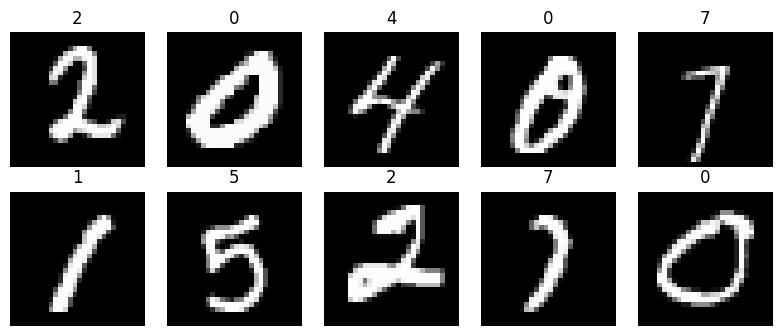

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.4))
for ax, image, label in zip(axes.ravel(), train_images[:10], train_labels[:10]):
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.tight_layout()

## Losowanie fragmentów `D x D`

Nie bierzemy wszystkich okien ze wszystkich obrazów, bo byłoby ich ponad 34 miliony. Losujemy ograniczoną pulę fragmentów i odrzucamy okna prawie puste. Warunek `MIN_PATCH_MEAN` oraz `MIN_ACTIVE_PIXELS` wymusza, żeby fragment zawierał istotny kawałek cyfry.

In [5]:
def sample_digit_patches(images, max_patches, source_images, D, min_mean, min_active_pixels, seed):
    generator = torch.Generator().manual_seed(seed)
    source_count = min(source_images, len(images))
    image_order = torch.randperm(len(images), generator=generator)[:source_count]
    unfold = torch.nn.Unfold(kernel_size=(D, D), stride=1)

    patches = []
    collected = 0

    for batch_idx in image_order.split(256):
        batch = images[batch_idx]
        windows = unfold(batch).transpose(1, 2).reshape(-1, D * D)
        mask = (windows.mean(dim=1) >= min_mean) & ((windows > 0.2).sum(dim=1) >= min_active_pixels)
        windows = windows[mask]

        if len(windows) == 0:
            continue

        need = max_patches - collected
        if len(windows) > need:
            chosen = torch.randperm(len(windows), generator=generator)[:need]
            windows = windows[chosen]

        patches.append(windows.cpu())
        collected += len(windows)

        if collected >= max_patches:
            break

    if collected < max_patches:
        print(f"Uwaga: zebrano tylko {collected} fragmentów z planowanych {max_patches}.")

    return torch.cat(patches, dim=0).numpy().astype(np.float32)


patches = sample_digit_patches(
    train_images,
    max_patches=PATCH_POOL_SIZE,
    source_images=PATCH_SOURCE_IMAGES,
    D=D,
    min_mean=MIN_PATCH_MEAN,
    min_active_pixels=MIN_ACTIVE_PIXELS,
    seed=SEED,
)

patches.shape, patches.mean(), patches.std()

((30000, 25), np.float32(0.43786797), np.float32(0.43691164))

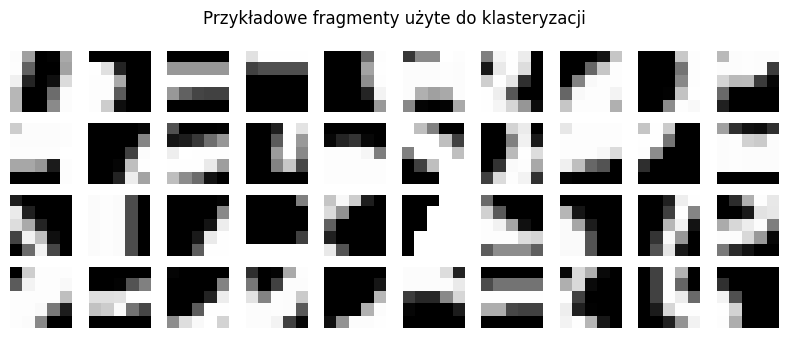

In [6]:
fig, axes = plt.subplots(4, 10, figsize=(8, 3.4))
sample_ids = rng.choice(len(patches), size=40, replace=False)
for ax, patch in zip(axes.ravel(), patches[sample_ids]):
    ax.imshow(patch.reshape(D, D), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle("Przykładowe fragmenty użyte do klasteryzacji")
plt.tight_layout()

## Klasteryzacja fragmentów

Środki klastrów są wzorcami. Dla każdego wzorca wyznaczamy osobny próg podobieństwa na podstawie odległości fragmentów przypisanych do klastra. Później wybierzemy najlepszy poziom kwantyla na zbiorze walidacyjnym.

In [7]:
kmeans = MiniBatchKMeans(
    n_clusters=K,
    batch_size=4096,
    n_init=5,
    max_iter=150,
    random_state=SEED,
)

cluster_ids = kmeans.fit_predict(patches)
patterns = np.clip(kmeans.cluster_centers_, 0.0, 1.0).astype(np.float32)

assigned_distances = np.linalg.norm(patches - patterns[cluster_ids], axis=1)
print(f"inertia={kmeans.inertia_:.2f}")
print(f"średnia odległość fragmentu od wzorca={assigned_distances.mean():.3f}")

inertia=28457.57
średnia odległość fragmentu od wzorca=0.922


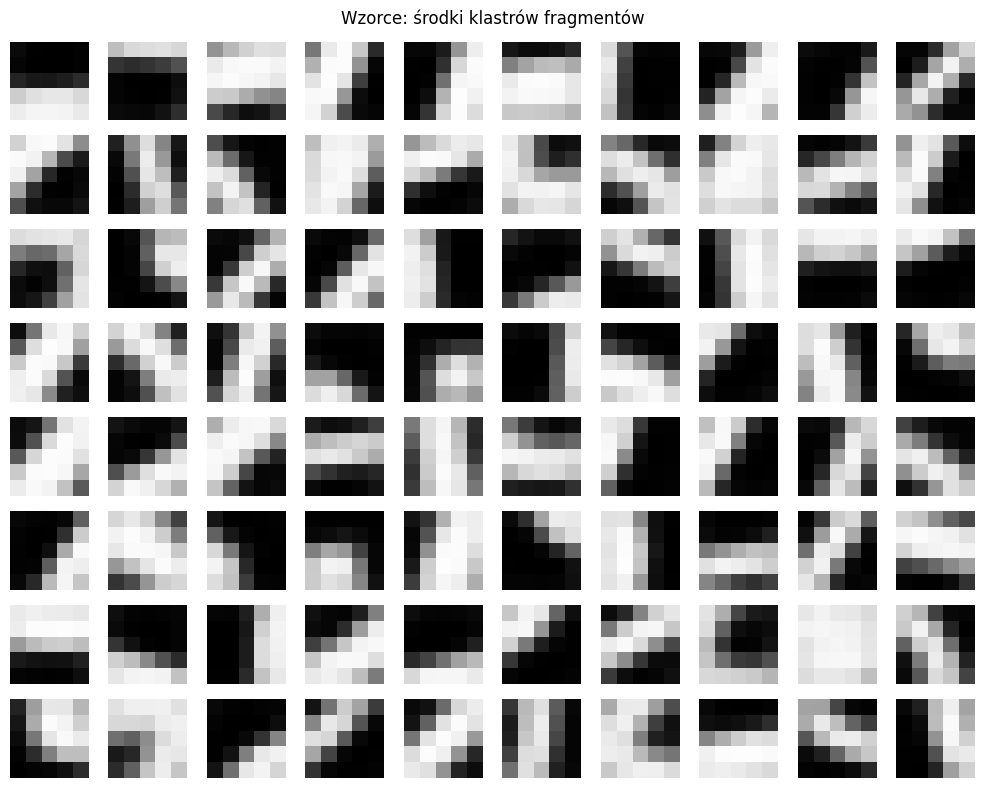

In [8]:
cols = 10
rows = int(np.ceil(K / cols))
fig, axes = plt.subplots(rows, cols, figsize=(10, rows))
for ax, pattern in zip(axes.ravel(), patterns):
    ax.imshow(pattern.reshape(D, D), cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
for ax in axes.ravel()[K:]:
    ax.axis("off")
plt.suptitle("Wzorce: środki klastrów fragmentów")
plt.tight_layout()

## Charakterystyki bitowe obrazów

Dla każdego obrazu i wzorca liczymy minimalną odległość euklidesową między wzorcem a dowolnym oknem `D x D` w obrazie. Jeśli minimum jest nie większe od progu danego wzorca, bit przyjmuje wartość 1.

Odległości są liczone splotowo z tożsamości:

`||okno - wzorzec||^2 = ||okno||^2 - 2 * <okno, wzorzec> + ||wzorzec||^2`.

In [9]:
def make_thresholds(cluster_ids, assigned_distances, K, quantile):
    thresholds = np.empty(K, dtype=np.float32)
    global_fallback = float(np.quantile(assigned_distances, quantile))

    for k in range(K):
        distances_k = assigned_distances[cluster_ids == k]
        if len(distances_k) == 0:
            thresholds[k] = global_fallback
        else:
            thresholds[k] = np.quantile(distances_k, quantile)

    return thresholds


@torch.no_grad()
def min_distances_to_patterns(images, patterns, D, batch_size=512, device="cpu"):
    pattern_tensor = torch.from_numpy(patterns.reshape(-1, 1, D, D)).to(device)
    ones = torch.ones((1, 1, D, D), device=device)
    pattern_norm = (pattern_tensor ** 2).sum(dim=(1, 2, 3)).view(1, -1, 1, 1)

    result = []
    for start in range(0, len(images), batch_size):
        batch = images[start:start + batch_size].to(device)
        patch_norm = F.conv2d(batch ** 2, ones)
        dot = F.conv2d(batch, pattern_tensor)
        dist2 = (patch_norm - 2.0 * dot + pattern_norm).clamp_min(0.0)
        min_dist = dist2.flatten(start_dim=2).min(dim=2).values.sqrt().cpu()
        result.append(min_dist)

    return torch.cat(result, dim=0).numpy().astype(np.float32)


def characteristics_from_distances(distances, thresholds):
    return distances <= thresholds.reshape(1, -1)


train_distances = min_distances_to_patterns(train_images, patterns, D, FEATURE_BATCH_SIZE, device)
valid_distances = min_distances_to_patterns(valid_images, patterns, D, FEATURE_BATCH_SIZE, device)

train_distances.shape, valid_distances.shape

((30000, 80), (10000, 80))

## Klasyfikator oparty o statystyki charakterystyk

Dla każdej zaobserwowanej charakterystyki przechowujemy wektor zliczeń etykiet `0..9`. Jeśli taka sama charakterystyka pojawia się w teście, wybieramy najczęstszą etykietę z tabeli. Jeśli charakterystyka nie była widziana w treningu, używamy najbliższych zaobserwowanych charakterystyk w odległości Hamminga i agregujemy ich statystyki. To zachowuje główną ideę zadania, a jednocześnie daje sensowne predykcje dla nowych ciągów bitów.

In [10]:
@dataclass
class CharacteristicStatsClassifier:
    n_neighbors: int = 9

    @staticmethod
    def _keys(X):
        packed = np.packbits(X.astype(np.uint8), axis=1)
        return [row.tobytes() for row in packed]

    def fit(self, X, y):
        X_uint = X.astype(np.uint8)
        keys = self._keys(X_uint)
        table = defaultdict(lambda: np.zeros(10, dtype=np.int64))
        first_vector = {}

        for key, vector, label in zip(keys, X_uint, y):
            table[key][int(label)] += 1
            if key not in first_vector:
                first_vector[key] = vector.copy()

        self.table_ = dict(table)
        self.keys_ = list(self.table_.keys())
        self.unique_X_ = np.vstack([first_vector[key] for key in self.keys_]).astype(np.uint8)
        self.unique_counts_ = np.vstack([self.table_[key] for key in self.keys_])
        self.default_label_ = int(np.bincount(y, minlength=10).argmax())

        neighbors = min(self.n_neighbors, len(self.unique_X_))
        self.nn_ = NearestNeighbors(n_neighbors=neighbors, metric="hamming", algorithm="brute")
        self.nn_.fit(self.unique_X_)
        return self

    def predict(self, X):
        X_uint = X.astype(np.uint8)
        keys = self._keys(X_uint)
        predictions = np.full(len(X_uint), self.default_label_, dtype=np.int64)
        unknown = []

        for i, key in enumerate(keys):
            counts = self.table_.get(key)
            if counts is None:
                unknown.append(i)
            else:
                predictions[i] = int(counts.argmax())

        if unknown:
            distances, neighbor_ids = self.nn_.kneighbors(X_uint[unknown], return_distance=True)
            for row, image_id in enumerate(unknown):
                scores = np.zeros(10, dtype=np.float64)
                for distance, neighbor_id in zip(distances[row], neighbor_ids[row]):
                    weight = 1.0 / (1e-3 + distance)
                    scores += weight * self.unique_counts_[neighbor_id]
                predictions[image_id] = int(scores.argmax())

        return predictions

    def exact_coverage(self, X):
        keys = self._keys(X.astype(np.uint8))
        return np.mean([key in self.table_ for key in keys])


def evaluate_quantile(quantile):
    thresholds = make_thresholds(cluster_ids, assigned_distances, K, quantile)
    X_train = characteristics_from_distances(train_distances, thresholds)
    X_valid = characteristics_from_distances(valid_distances, thresholds)

    classifier = CharacteristicStatsClassifier(n_neighbors=9).fit(X_train, train_labels)
    pred = classifier.predict(X_valid)
    return {
        "quantile": quantile,
        "thresholds": thresholds,
        "accuracy": accuracy_score(valid_labels, pred),
        "exact_coverage": classifier.exact_coverage(X_valid),
        "avg_active_bits": X_valid.sum(axis=1).mean(),
        "unique_characteristics": len(classifier.keys_),
    }


validation_results = [evaluate_quantile(q) for q in THRESHOLD_QUANTILES]
for result in validation_results:
    print(
        f"q={result['quantile']:.2f}  "
        f"valid_acc={result['accuracy']:.4f}  "
        f"exact={result['exact_coverage']:.3f}  "
        f"avg_bits={result['avg_active_bits']:.1f}  "
        f"unique={result['unique_characteristics']}"
    )

best_result = max(validation_results, key=lambda item: item["accuracy"])
thresholds = best_result["thresholds"]
print("\nWybrany kwantyl:", best_result["quantile"])

q=0.45  valid_acc=0.6767  exact=0.009  avg_bits=38.6  unique=29869
q=0.55  valid_acc=0.6872  exact=0.008  avg_bits=43.4  unique=29867
q=0.65  valid_acc=0.6664  exact=0.010  avg_bits=48.2  unique=29840
q=0.75  valid_acc=0.6539  exact=0.013  avg_bits=53.3  unique=29767
q=0.85  valid_acc=0.6168  exact=0.065  avg_bits=59.3  unique=28649

Wybrany kwantyl: 0.55


## Ocena na zbiorze testowym

Po wyborze progu trenujemy końcowy klasyfikator na połączonym zbiorze treningowym i walidacyjnym, a wynik raportujemy na oryginalnym zbiorze testowym MNIST.

In [11]:
full_train_images = torch.cat([train_images, valid_images], dim=0)
full_train_labels = np.concatenate([train_labels, valid_labels])
full_train_distances = np.vstack([train_distances, valid_distances])

X_full_train = characteristics_from_distances(full_train_distances, thresholds)

test_distances = min_distances_to_patterns(test_images, patterns, D, FEATURE_BATCH_SIZE, device)
X_test = characteristics_from_distances(test_distances, thresholds)

classifier = CharacteristicStatsClassifier(n_neighbors=9).fit(X_full_train, full_train_labels)
test_pred = classifier.predict(X_test)

test_accuracy = accuracy_score(test_labels, test_pred)
print(f"Liczba wzorców K: {K}")
print(f"Długość charakterystyki: {X_test.shape[1]} bitów")
print(f"Średnia liczba aktywnych bitów w teście: {X_test.sum(axis=1).mean():.2f}")
print(f"Liczba różnych charakterystyk w treningu: {len(classifier.keys_)}")
print(f"Pokrycie dokładnych charakterystyk w teście: {classifier.exact_coverage(X_test):.3f}")
print(f"Accuracy na zbiorze testowym: {test_accuracy:.4f}")

Liczba wzorców K: 80
Długość charakterystyki: 80 bitów
Średnia liczba aktywnych bitów w teście: 44.03
Liczba różnych charakterystyk w treningu: 39785
Pokrycie dokładnych charakterystyk w teście: 0.011
Accuracy na zbiorze testowym: 0.6837


In [12]:
print(classification_report(test_labels, test_pred, digits=4))

              precision    recall  f1-score   support

           0     0.4666    0.8551    0.6037       980
           1     0.8432    0.9903    0.9109      1135
           2     0.6329    0.4545    0.5290      1032
           3     0.6652    0.7693    0.7135      1010
           4     0.8462    0.7902    0.8173       982
           5     0.5729    0.4978    0.5327       892
           6     0.6420    0.5522    0.5937       958
           7     0.8340    0.8502    0.8420      1028
           8     0.6384    0.3552    0.4565       974
           9     0.7710    0.6541    0.7078      1009

    accuracy                         0.6837     10000
   macro avg     0.6912    0.6769    0.6707     10000
weighted avg     0.6954    0.6837    0.6763     10000



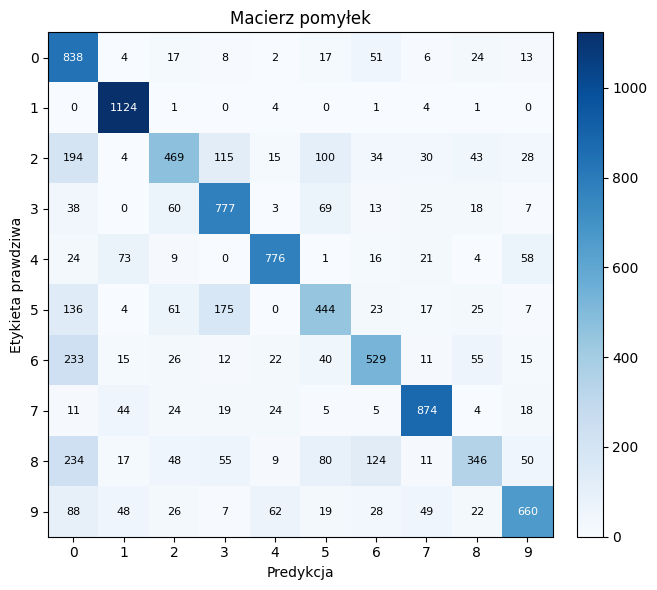

In [13]:
cm = confusion_matrix(test_labels, test_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xlabel("Predykcja")
ax.set_ylabel("Etykieta prawdziwa")
ax.set_xticks(range(10))
ax.set_yticks(range(10))

for i in range(10):
    for j in range(10):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=8)

plt.title("Macierz pomyłek")
plt.tight_layout()

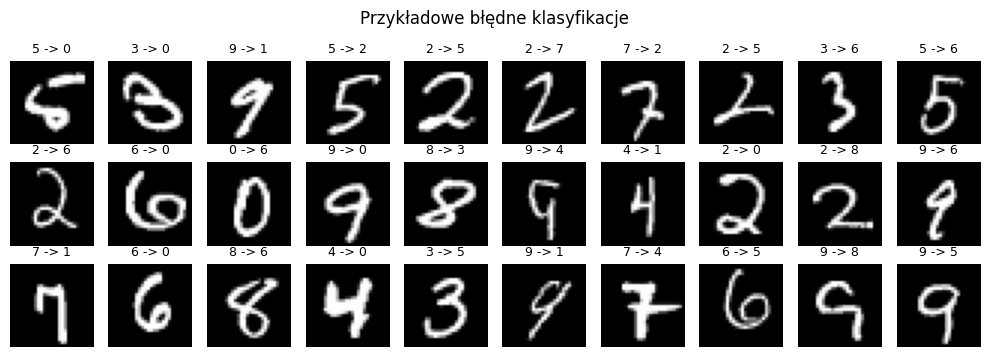

In [14]:
mistakes = np.flatnonzero(test_pred != test_labels)
shown = min(30, len(mistakes))

if shown == 0:
    print("Brak błędów w pokazanej części testowej.")
else:
    fig, axes = plt.subplots(3, 10, figsize=(10, 3.6))
    for ax in axes.ravel():
        ax.axis("off")

    for ax, image_id in zip(axes.ravel(), mistakes[:shown]):
        ax.imshow(test_images[image_id].squeeze(), cmap="gray")
        ax.set_title(f"{test_labels[image_id]} -> {test_pred[image_id]}", fontsize=9)
        ax.axis("off")

    plt.suptitle("Przykładowe błędne klasyfikacje")
    plt.tight_layout()

## Podsumowanie metody

Najważniejsze decyzje projektowe:

- fragmenty prawie puste są odrzucane, żeby klastery reprezentowały części cyfr, a nie tło,
- liczba wzorców `K = 80` daje bogatszy opis niż kilka prostych kształtów, ale nie powoduje jeszcze bardzo długiej charakterystyki,
- próg podobieństwa jest osobny dla każdego wzorca, ponieważ różne klastry mają różną zmienność,
- predykcja dla znanej charakterystyki używa dokładnie statystyk etykiet tej charakterystyki,
- dla nieznanej charakterystyki zastosowano łagodny fallback: najbliższe znane charakterystyki w odległości Hamminga.

Taka konstrukcja jest prostym odpowiednikiem bardzo płytkiej sieci splotowej: wzorce są filtrami, ich wystąpienia tworzą binarne mapy cech, a klasyfikacja korzysta ze statystyk aktywacji filtrów.